# RFM-анализ клиентской базы аптечной сети

### Цель проекта

В условиях сезонного снижения выручки аптечная сеть планирует использовать SMS-рассылки для стимулирования повторных покупок и увеличения выручки.

### Цели исследования

- Провести классификацию пользователей  
- Сформировать рекомендации по коммуникациям для каждой группы пользователей  

### Струкура данных

Для исследования использовалась таблица Bonuscheques, которая содержит информацию о транзакциях по бонусным картам card.

Если в момент покупки касса была в оффлайн-режиме (карта клиента не использовалась), то вместо номера карты card записывается зашифрованная последовательность символов. Такие данные в расчет не брал. В исследование взяты покупки, которые можно идентифицировать.

**Таблица включает в себя следующие столбцы:**

- `datetime` - дата и время совершения транзакции
- `shop` - наименование аптеки
- `card` - номер карты
- `bonus_earned` - количество полученных бонусов
- `bonus_spent` - количество списанных бонусов
- `summ` - итоговая сумма чека
- `doc_id` - номер документа

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text

In [37]:
load_dotenv()

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)

engine = create_engine(DATABASE_URL)

In [38]:
plt.rcParams['figure.figsize'] = (12, 6)

In [39]:
def draw_plot(df, kind='bar', x=None, y=None, legend=False, 
              title='', xlabel='', ylabel=''):

    ax = df.plot(
        kind=kind,
        x=x,
        y=y,
        legend=legend,
        color=['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c']
    )

    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    plt.xticks(
        rotation=45,
        ha='right',
        fontsize=11
    )

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=10,
            padding=3
        )

    plt.tight_layout()
    plt.show()

In [40]:
def run_sql(filename):
    query = Path(f"sql/{filename}.sql").read_text(encoding="utf-8")
    return pd.read_sql(text(query), engine)

Выполним RFM-анализ клиентов (Recency, Frequency, Monetary), чтобы выделить поведенческие сегменты и определить наиболее ценные и рискованные группы пользователей.

In [41]:
rfm = run_sql("rfm_segmentation")
rfm

,segment,customers,total_customers,avg_purchases,avg_revenue_per_customer,avg_days_since_purchase,customer_share_pct
0,Лояльные,2135,5926.0,3.08,2922.77,80.8,36.03
1,Потерянные,1176,5926.0,1.04,597.72,227.6,19.84
2,Чемпионы,964,5926.0,11.51,10759.18,24.4,16.27
3,Под угрозой,849,5926.0,1.44,1210.53,100.4,14.33
4,Нельзя терять,802,5926.0,1.20,1065.11,153.2,13.53


### Распределение клиентов по RFM-сегментам

На данном графике посмотрим размер каждого клиентского сегмента. 

График позволит увидеть, какие группы занимают наибольшую долю клиентской базы.

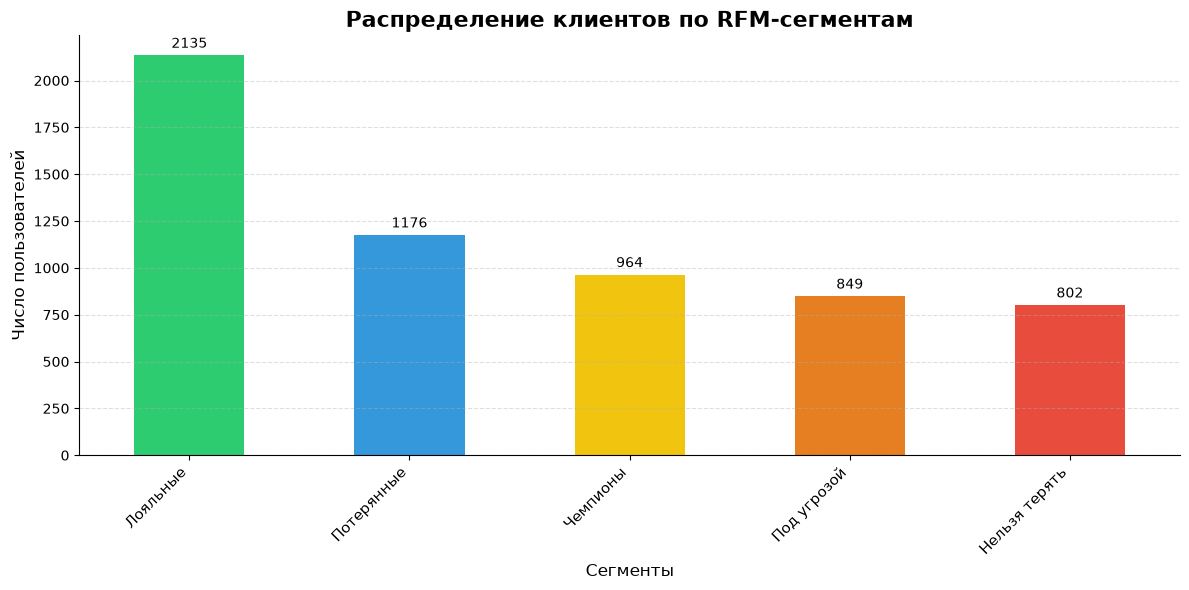

In [42]:
draw_plot(
    rfm,
    kind='bar',
    x='segment',
    y='customers',
    legend=False,
    title='Распределение клиентов по RFM-сегментам',
    xlabel='Сегменты',
    ylabel='Число пользователей'
)

#### Вывод

В выборке преобладают лояльные клиенты (2 135 человек), но также выделяется значительная группа потерянных (1 176 человек). Это говорит о наличии устойчивой активной базы, при этом часть клиентов потеряла интерес и требует целевых мер по возврату

### Средняя выручка на одного клиента в сегментах

Посмотрим на среднюю ценность одного клиента внутри каждого сегмента.

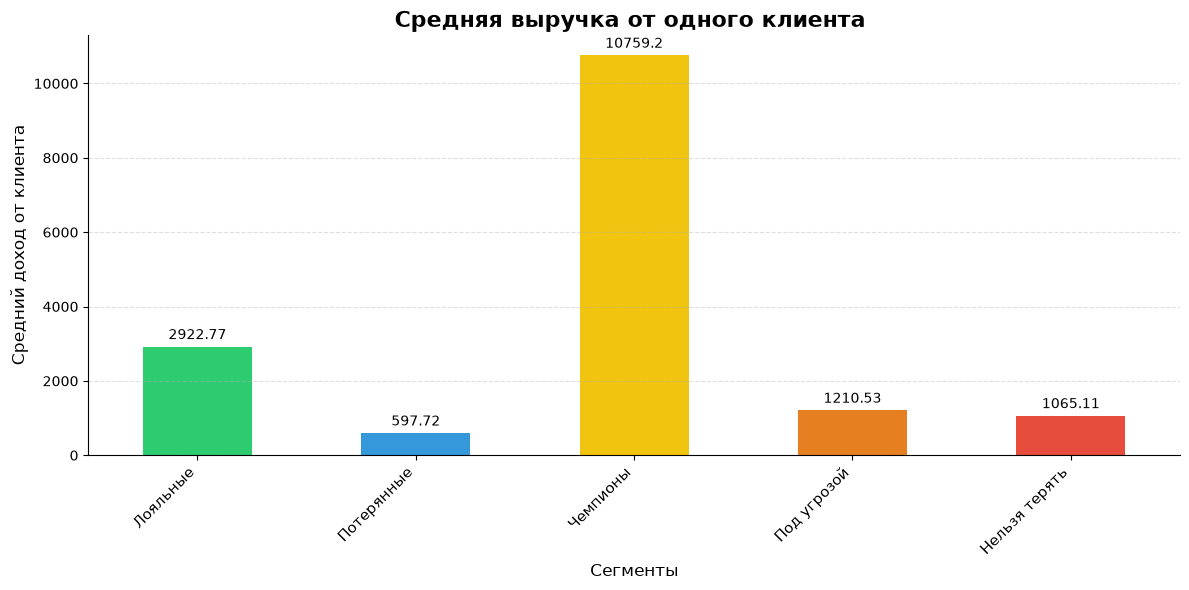

In [43]:
draw_plot(
    rfm,
    kind='bar',
    x='segment',
    y='avg_revenue_per_customer',
    legend=False,
    title='Средняя выручка от одного клиента ',
    xlabel='Сегменты',
    ylabel='Средний доход от клиента'
)

#### Вывод

Сегмент **Чемпионы** значительно превосходит остальные группы по средней выручке на одного клиента.

Это говорит о высокой ценности данной категории клиентов: они совершают покупки чаще и формируют больший вклад в оборот.

### Частота покупок по RFM-сегментам

Посмотрим на среднее количество покупок клиентов в каждом сегменте.

Показатель позволяет оценить уровень вовлеченности клиентов.

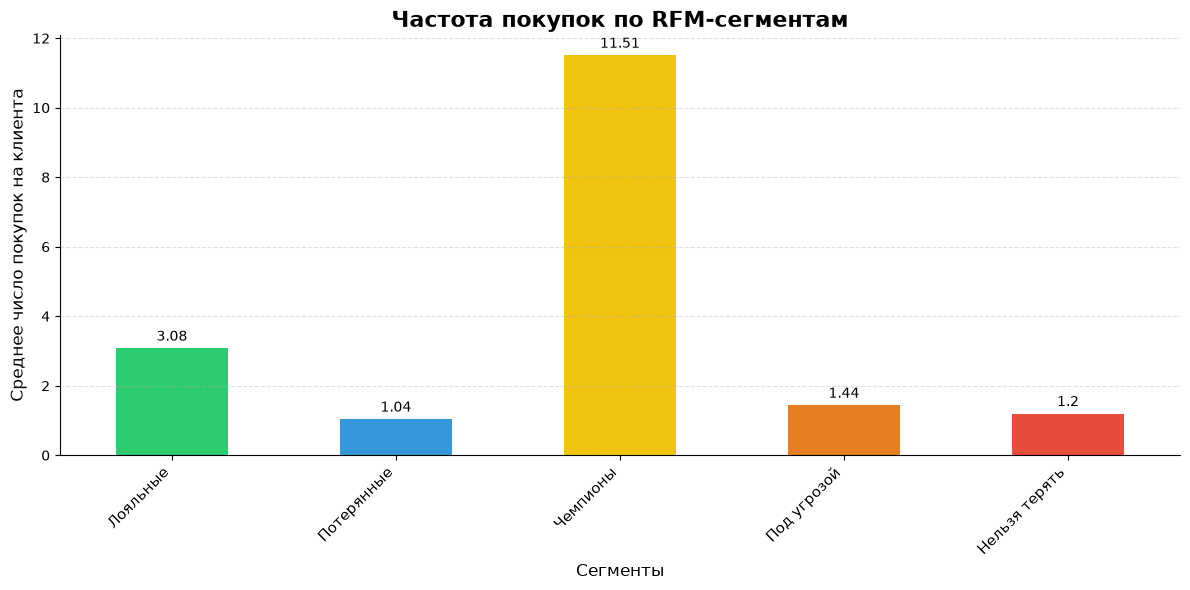

In [44]:
draw_plot(
    rfm,
    kind='bar',
    x='segment',
    y='avg_purchases',
    legend=False,
    title='Частота покупок по RFM-сегментам',
    xlabel='Сегменты',
    ylabel='Среднее число покупок на клиента'
)


#### Вывод

Клиенты сегмента **Чемпионы** имеют значительно более высокую частоту покупок.

Среднее количество покупок у данной группы существенно превышает показатели остальных сегментов, что подтверждает их высокий уровень вовлеченности.

Клиенты сегментов «Под угрозой» и «Потерянные» демонстрируют низкую активность и требуют стимулирующих мероприятий.

### Структура клиентской базы

Построим круговую диаграмму, что бы посмотреть долю каждого RFM-сегмента в общей клиентской базе.

Это позволяет оценить структуру аудитории и определить преобладающие категории клиентов.

<Axes: title={'center': 'Распределение клиентов по RFM-сегментам'}>

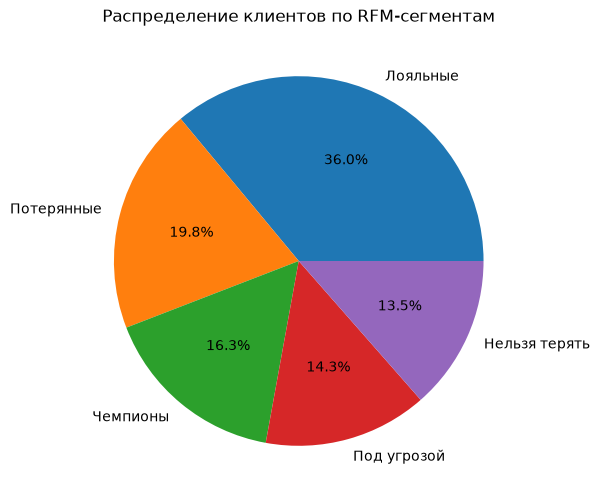

In [45]:
rfm.plot(
    kind='pie',
    y='customer_share_pct',
    labels=rfm['segment'],
    autopct='%1.1f%%',
    title='Распределение клиентов по RFM-сегментам',
    legend=False
)

#### Вывод

Основную часть клиентской базы формируют сегменты **Лояльные** и **Потерянные**.

Наличие большого количества потерянных клиентов является потенциальной зоной роста: даже частичный возврат данной аудитории может положительно повлиять на будущую выручку.

При этом сегмент **Чемпионы**, несмотря на меньшую численность, представляет наибольшую ценность для бизнеса.

## Общие выводы RFM-анализа

RFM-анализ позволил разделить клиентов на группы с различным уровнем активности и ценности.

Основные результаты:
- сегмент **Чемпионы** является наиболее ценным и требует максимального внимания для удержания
- **Лояльные** клиенты формируют основу стабильной клиентской базы
- **Под угрозой** и **Нельзя терять** являются приоритетной аудиторией для реактивации
- **Потерянные** клиенты требуют анализа причин ухода и оценки целесообразности возвратных кампаний

Полученная сегментация может использоваться для персонализации маркетинговых коммуникаций и повышения эффективности работы с клиентской базой.

#### Основные точки роста

По результатам анализа основными направлениями развития клиентской базы являются:

- **удержание и развитие сегментов 'Чемпионы' и 'Лояльные'**, так как они формируют основную ценность для бизнеса
- **реактивация клиентов сегментов 'Под угрозой' и 'Нельзя терять'**, поскольку данные группы уже имеют историю взаимодействия и могут быть возвращены с меньшими затратами, чем привлечение новых клиентов
- **оценка эффективности win-back кампаний для 'Потерянных клиентов'** с целью определить экономическую целесообразность их возврата
- **персонализация маркетинговых коммуникаций** на основе поведения и ценности клиентов.

#### Бизнес-рекомендации по результатам RFM-анализа

На основе выявленных RFM-сегментов были сформированы рекомендации по работе с каждой группой клиентов.

| Сегмент | Рекомендуемая стратегия |
|--------------|-----------------------------------------------|
| **Чемпионы** | Удержание и развитие наиболее ценных клиентов: программа лояльности с накопительными бонусами, ранний доступ к новым продуктам, персональные предложения и подарки. |
| **Лояльные** | Укрепление долгосрочных отношений: программа «приведи друга», кросс-продажи в смежные категории, персонализированные рекомендации. |
| **Под угрозой** | Реактивация клиентов: персональные предложения на основе истории покупок, напоминания о повторной покупке, бонусы за возвращение. |
| **Нельзя терять** | Приоритетная win-back стратегия: индивидуальные предложения, специальные условия и стимулирующие скидки для восстановления активности. |
| **Потерянные** | Оптимизация затрат на коммуникации: ограничение массовых маркетинговых кампаний, использование данных преимущественно для аналитики и построения look-alike аудиторий. |

### ABC-анализ клиентов по вкладу в выручку

#### Цель ABC-анализа

RFM-анализ позволяет оценить активность и ценность клиентов на основе давности покупок, частоты и объема расходов.

Однако RFM не показывает, какую долю общей выручки формируют отдельные клиенты.

Для определения экономической значимости клиентов дополнительно проведем ABC-анализ, который распределит клиентов по вкладу в общую выручку:
- **A** — клиенты, формирующие основную часть оборота
- **B** — клиенты со средним вкладом
- **C** — клиенты с небольшим вкладом в выручку